<a href="https://colab.research.google.com/github/MyCodeChris/Floodpredict/blob/Master/ML_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report


In [2]:
cols = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Dataset is from UCI data portal

In [3]:
df["class"] = (df["class"] == "g").astype(int)
print(df)

        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  class  
0       -8.2027  40.0920   81.8828      1  
1       -9.9574   6.3609  205.2610 

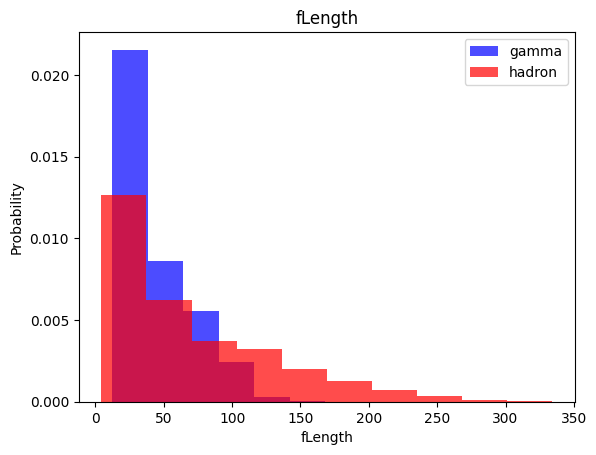

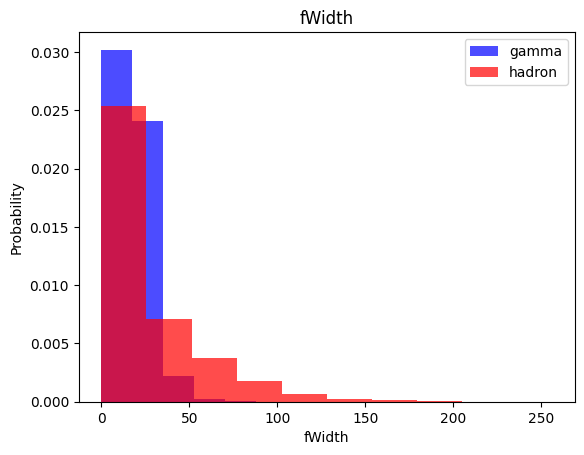

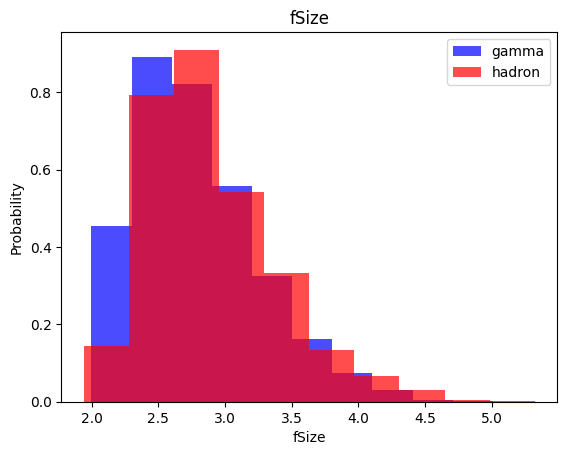

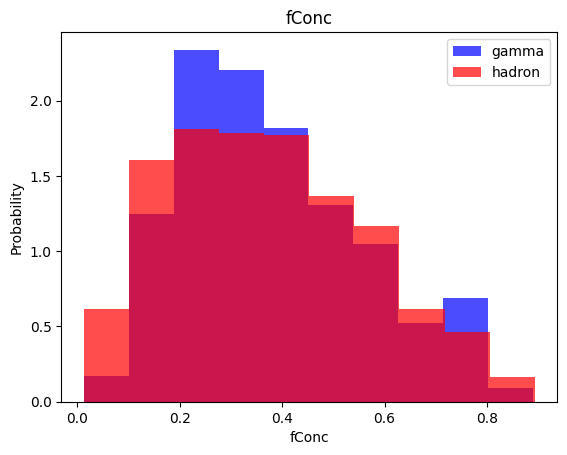

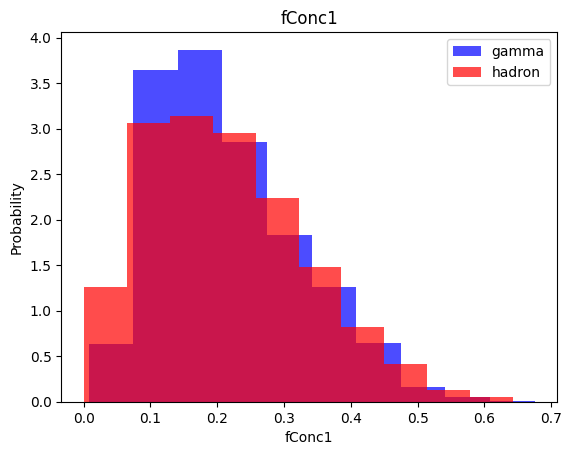

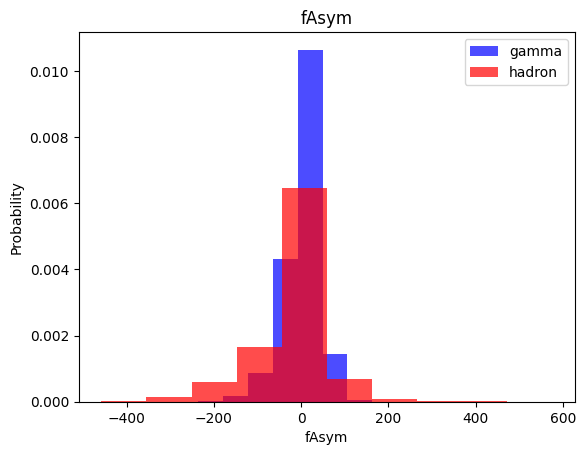

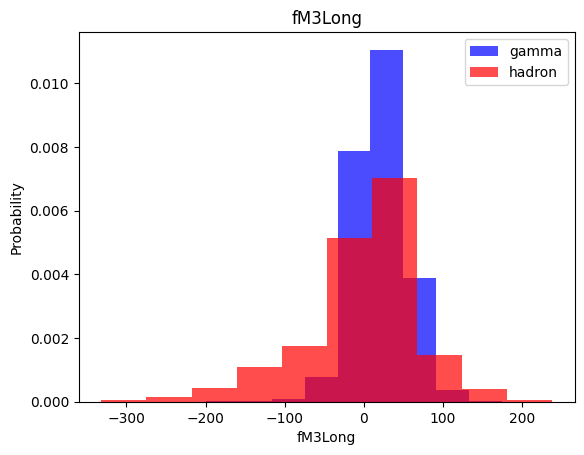

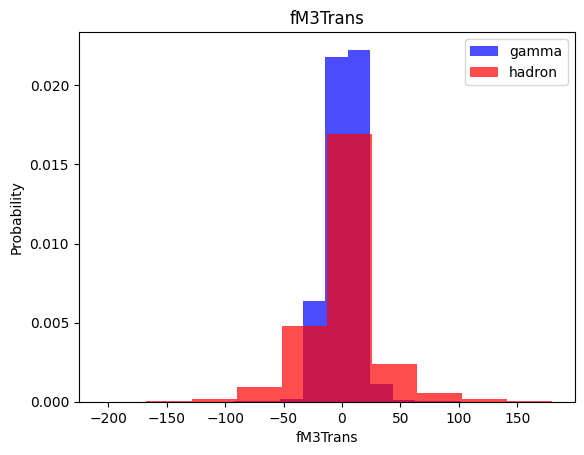

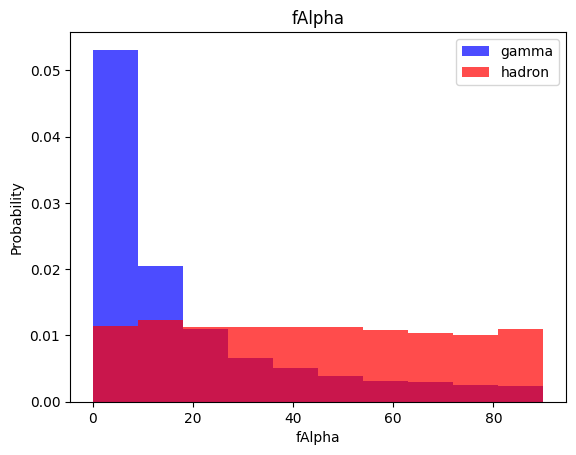

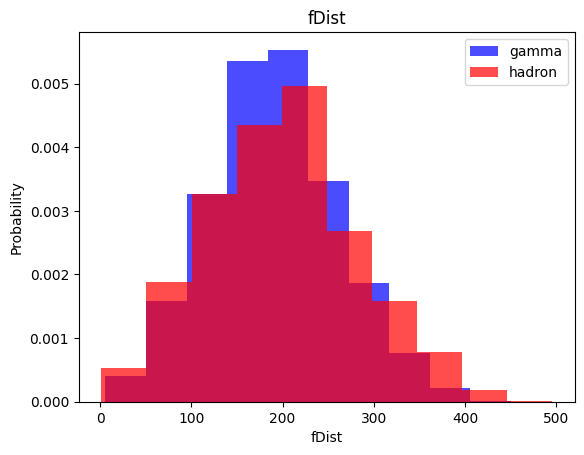

In [4]:
for label in cols[:-1]:
  plt.hist(df[df["class"] == 1][label], color='blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"] == 0][label], color='red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

Train, Validation, and test

In [5]:
# Split the DataFrame into train, valid, and test sets
train, valid, test = np.split(df.sample(frac=1, random_state=42), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [6]:
def scale_dataset(dataframe, oversample=False):
    # Extract features (X) and target (y)
    x = dataframe.iloc[:, :-1].values  # All columns except the last
    y = dataframe.iloc[:, -1].values  # Only the last column (target)

    # Standardize the feature columns
    scaler = StandardScaler()
    x = scaler.fit_transform(x)

    # Perform oversampling if required
    if oversample:
        ros = RandomOverSampler(random_state=42)
        x, y = ros.fit_resample(x, y)

    # Combine the scaled features and target for convenience
    data = np.hstack((x, np.reshape(y, (-1, 1))))
    return data, x, y


In [7]:
# Apply the function to each dataset
train, x_train, y_train = scale_dataset(train, oversample=True)
valid, x_valid, y_valid = scale_dataset(valid, oversample=False)
test, x_test, y_test = scale_dataset(test, oversample=False)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Try k-NN Algorithm

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1331
           1       0.86      0.86      0.86      2473

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model = nb_model.fit(x_train, y_train)

In [ ]:
y_pred = nb_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1331
           1       0.73      0.89      0.80      2473

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.71      0.72      0.69      3804



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train, y_train)

In [ ]:
y_pred = lg_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1331
           1       0.84      0.81      0.82      2473

    accuracy                           0.77      3804
   macro avg       0.75      0.76      0.76      3804
weighted avg       0.78      0.77      0.78      3804



Support Vector Machine

In [ ]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model = svm_model.fit(x_train, y_train)

In [ ]:
y_pred = svm_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79      1331
           1       0.89      0.90      0.89      2473

    accuracy                           0.86      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.86      0.86      0.86      3804



NEURAL NETWORK

In [18]:
import tensorflow as tf

def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
  # Plot Loss
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy loss')
  ax1.legend()
  ax1.grid(True)


  #plot_accuracy
  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label = 'val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  plt.legend()
  plt.grid(True)
  # Display the plots
  plt.show()


'''def train_model(x_train, y_train, num_node, lr, dropout_prob, batch_size, epochs):
  nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(32, activation='relu'),
         tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
  ])
'''
def train_model(x_train, y_train, num_node, lr, dropout_prob, batch_size, epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(10,)),  # Correct way to specify input shape
        tf.keras.layers.Dense(num_node, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_node, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(optimizer=tf.optimizers.Adam(lr),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
    history = nn_model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=0
    )
    return nn_model, history

16 nodes, dropout0, lr 0.01, batch_size 32


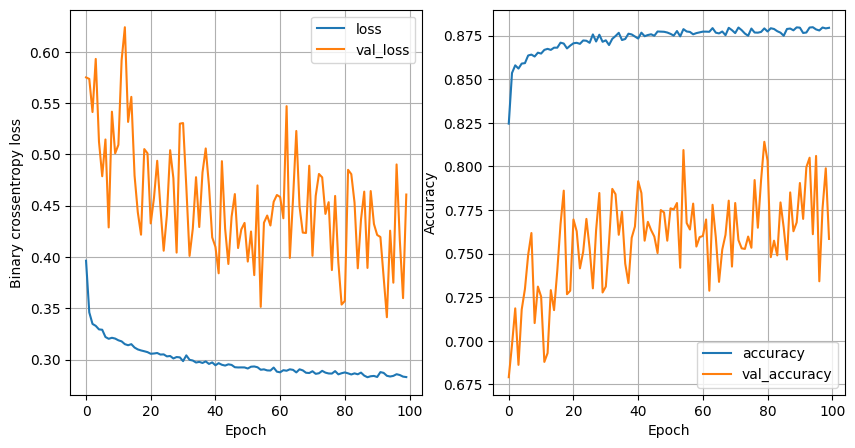

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8786 - loss: 0.3087
16 nodes, dropout0, lr 0.01, batch_size 64


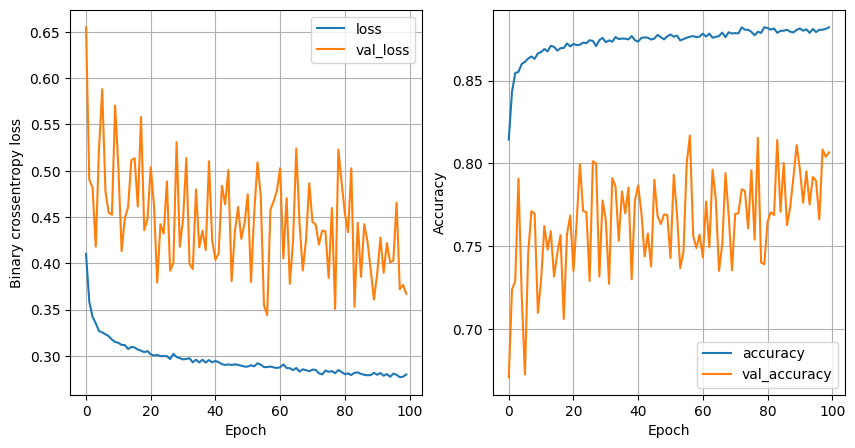

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8747 - loss: 0.3079
16 nodes, dropout0, lr 0.01, batch_size 128


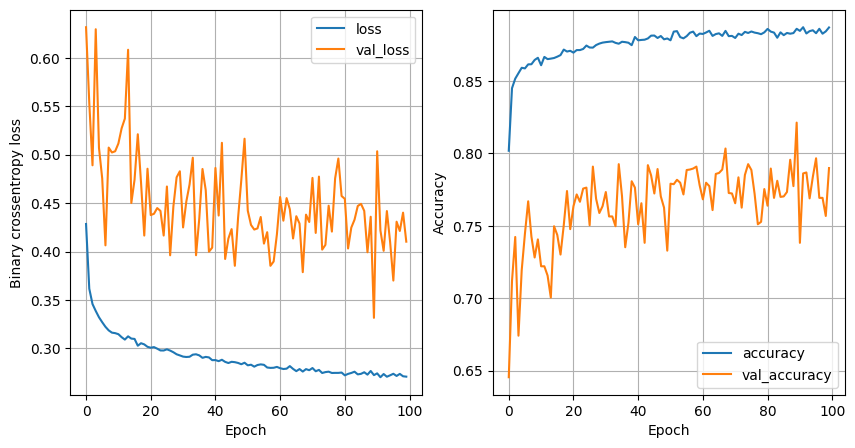

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8792 - loss: 0.3048
16 nodes, dropout0, lr 0.005, batch_size 32


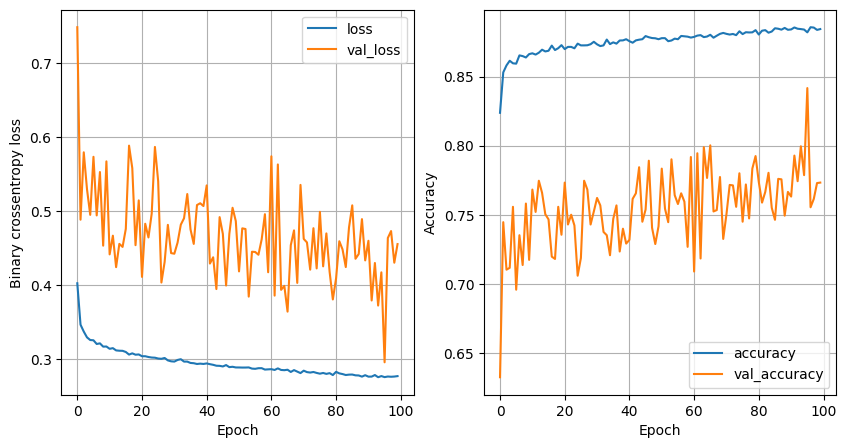

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8778 - loss: 0.3037
16 nodes, dropout0, lr 0.005, batch_size 64


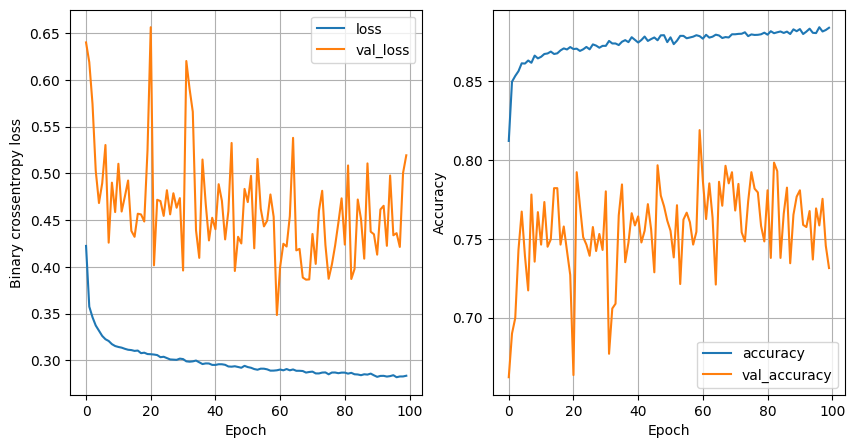

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8764 - loss: 0.3081
16 nodes, dropout0, lr 0.005, batch_size 128


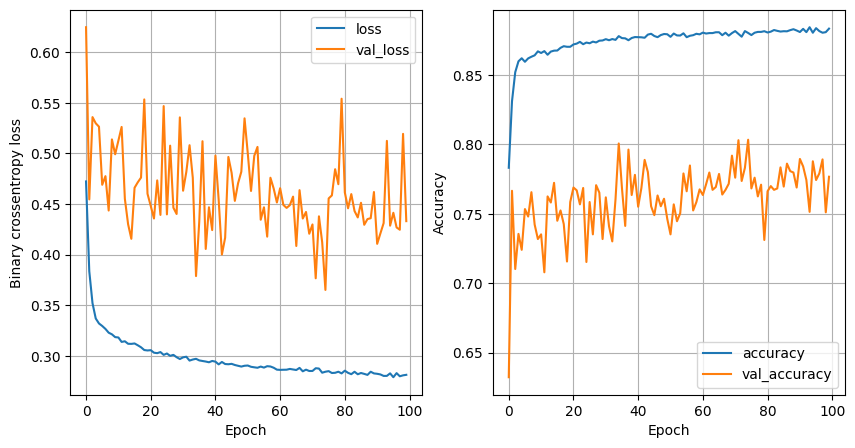

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8762 - loss: 0.3038
16 nodes, dropout0, lr 0.0001, batch_size 32


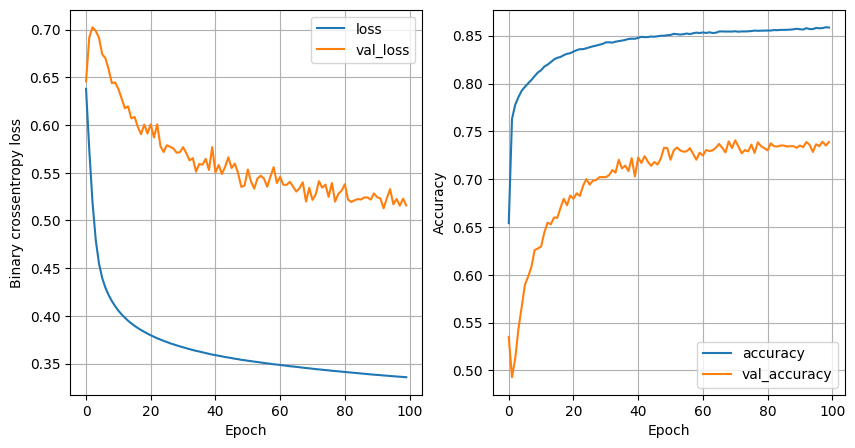

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8649 - loss: 0.3238
16 nodes, dropout0, lr 0.0001, batch_size 64


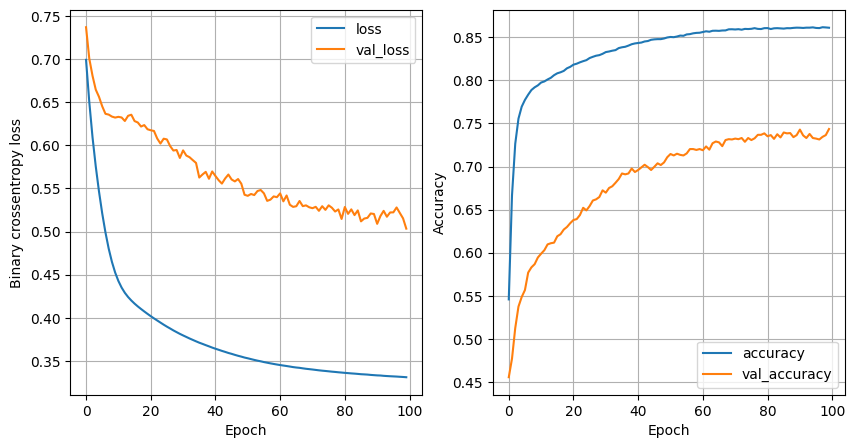

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8708 - loss: 0.3197
16 nodes, dropout0, lr 0.0001, batch_size 128


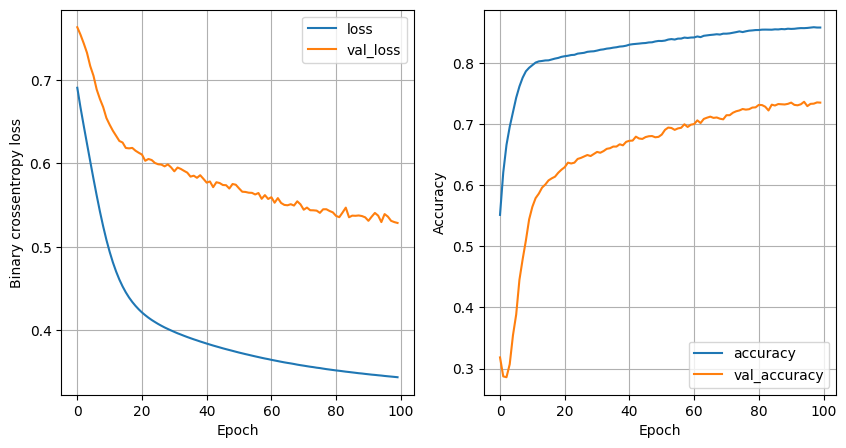

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8617 - loss: 0.3285
16 nodes, dropout0.2, lr 0.01, batch_size 32


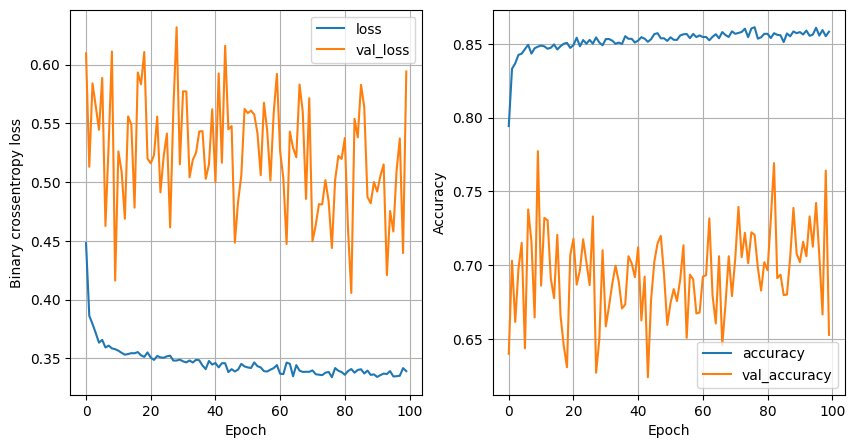

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8610 - loss: 0.3228
16 nodes, dropout0.2, lr 0.01, batch_size 64


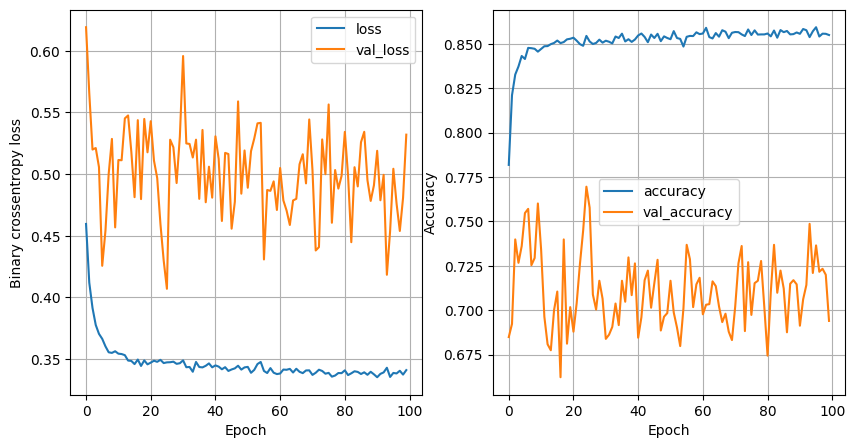

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8668 - loss: 0.3117
16 nodes, dropout0.2, lr 0.01, batch_size 128


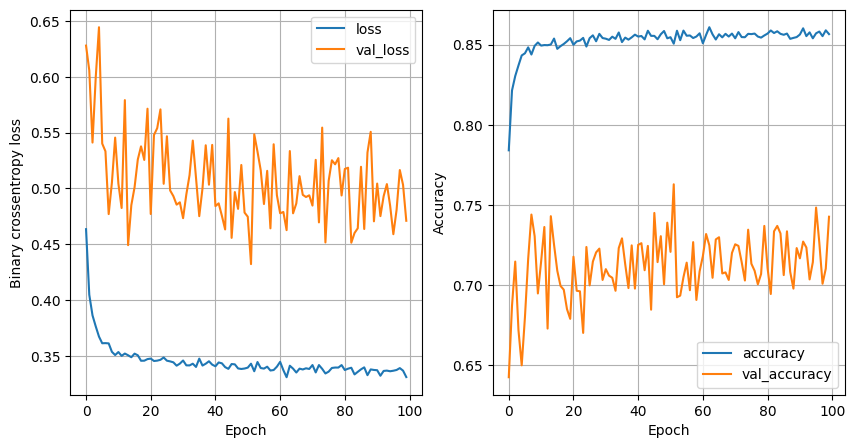

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8728 - loss: 0.3096
16 nodes, dropout0.2, lr 0.005, batch_size 32


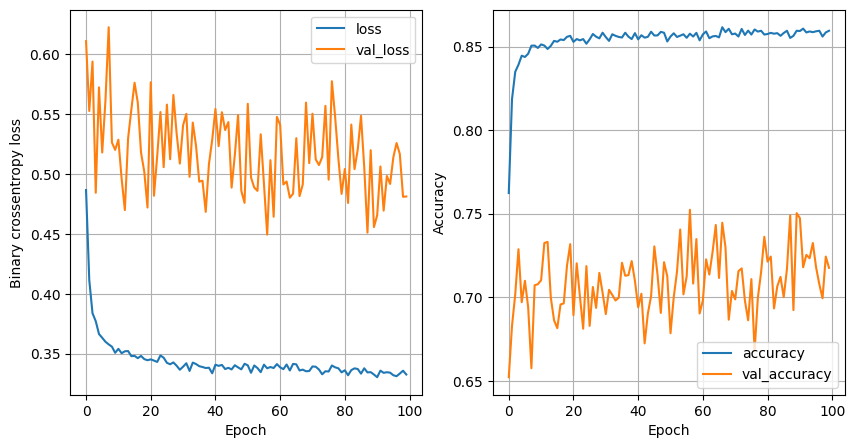

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8711 - loss: 0.3062
16 nodes, dropout0.2, lr 0.005, batch_size 64


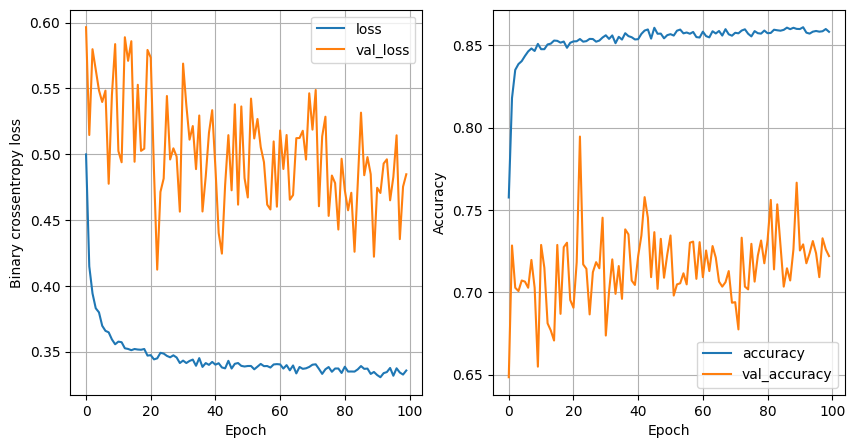

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8708 - loss: 0.3107
16 nodes, dropout0.2, lr 0.005, batch_size 128


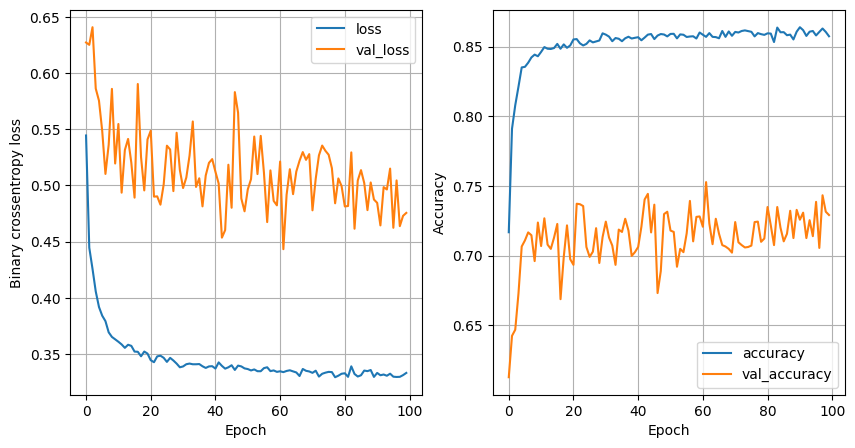

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8710 - loss: 0.3044
16 nodes, dropout0.2, lr 0.0001, batch_size 32


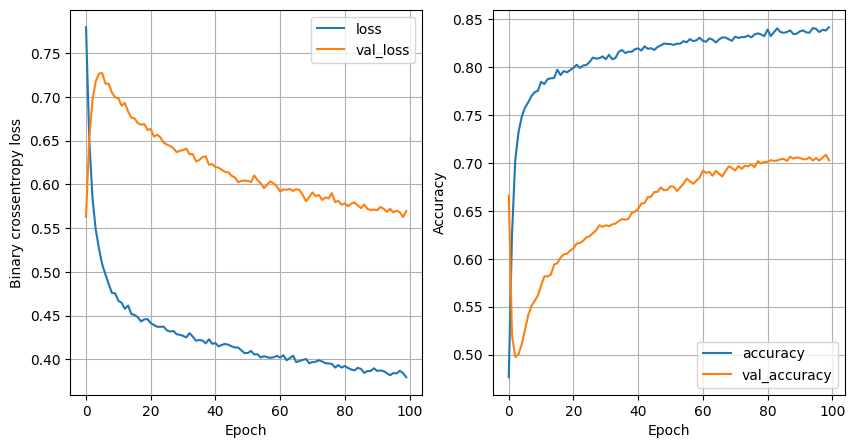

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8668 - loss: 0.3380
16 nodes, dropout0.2, lr 0.0001, batch_size 64


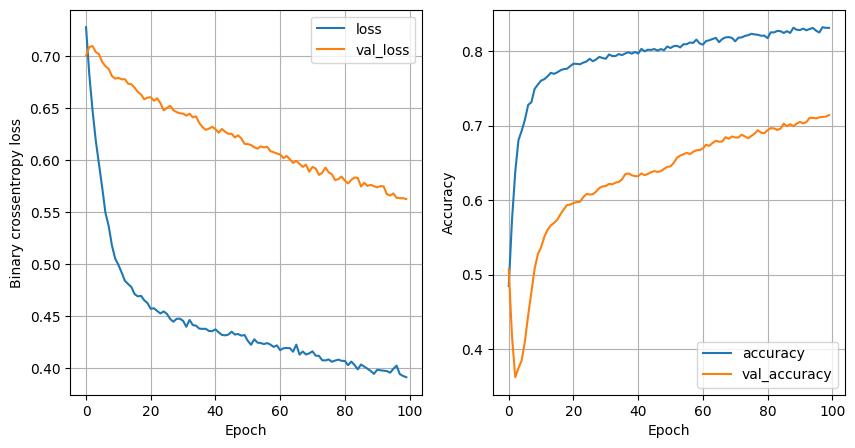

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8633 - loss: 0.3460
16 nodes, dropout0.2, lr 0.0001, batch_size 128


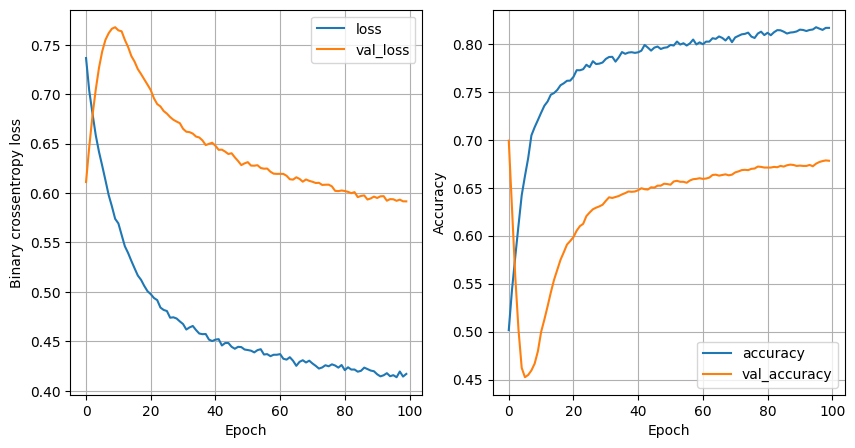

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8537 - loss: 0.3635
32 nodes, dropout0, lr 0.01, batch_size 32


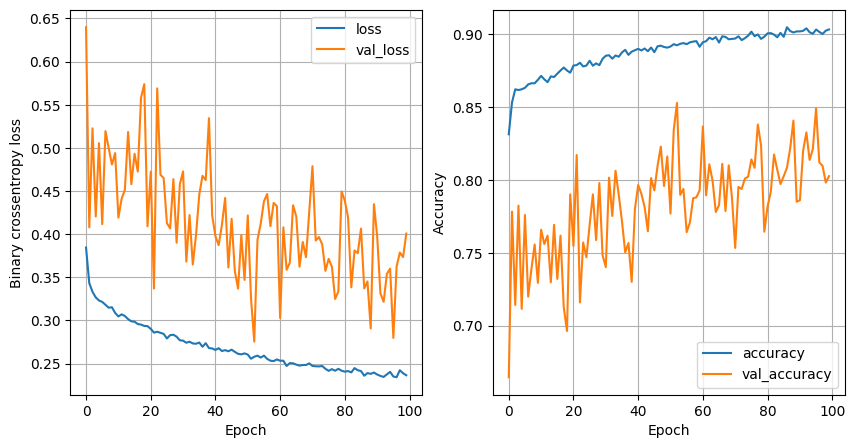

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8757 - loss: 0.3522
32 nodes, dropout0, lr 0.01, batch_size 64


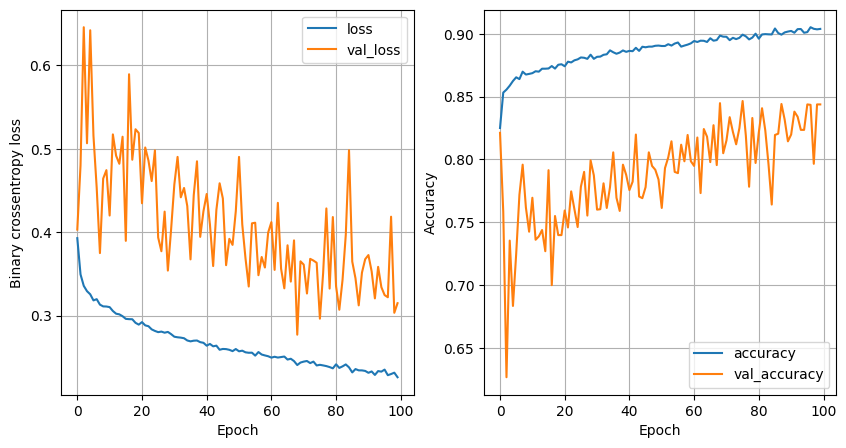

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8704 - loss: 0.3656
32 nodes, dropout0, lr 0.01, batch_size 128


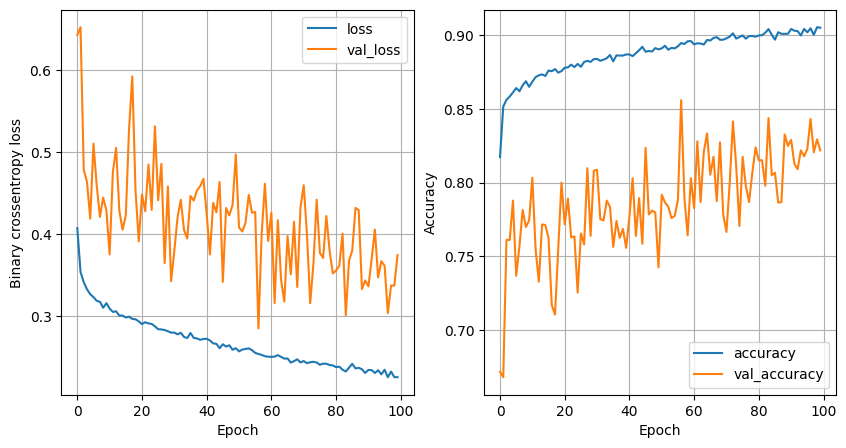

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8773 - loss: 0.3710
32 nodes, dropout0, lr 0.005, batch_size 32


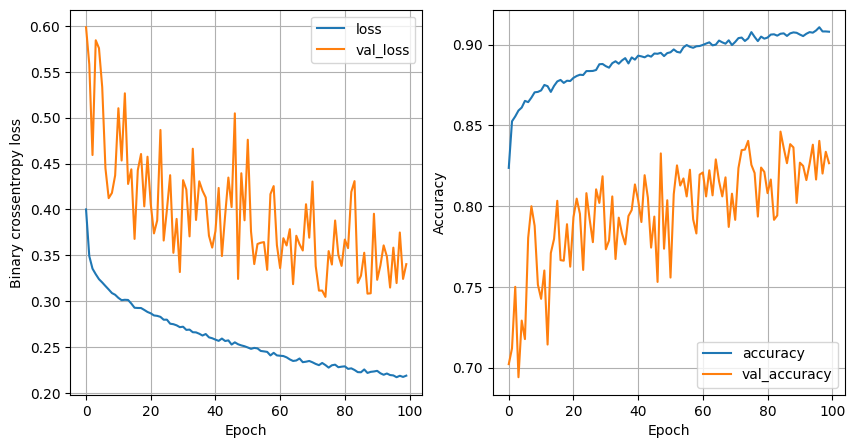

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8725 - loss: 0.3728
32 nodes, dropout0, lr 0.005, batch_size 64


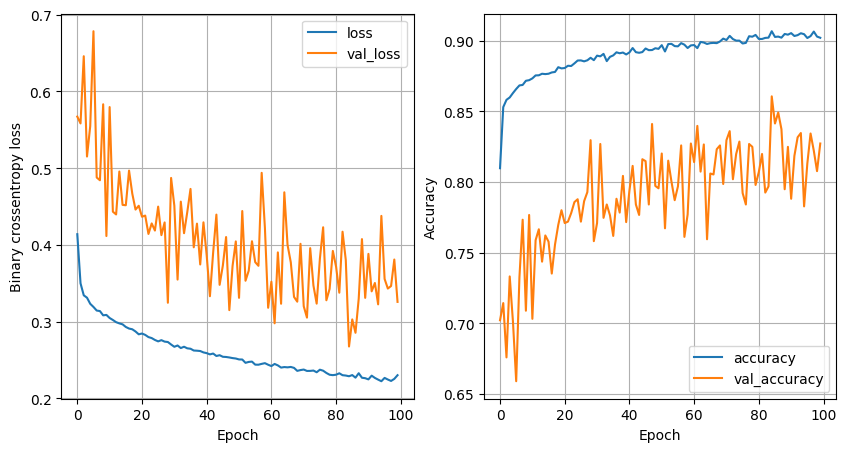

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8753 - loss: 0.3538
32 nodes, dropout0, lr 0.005, batch_size 128


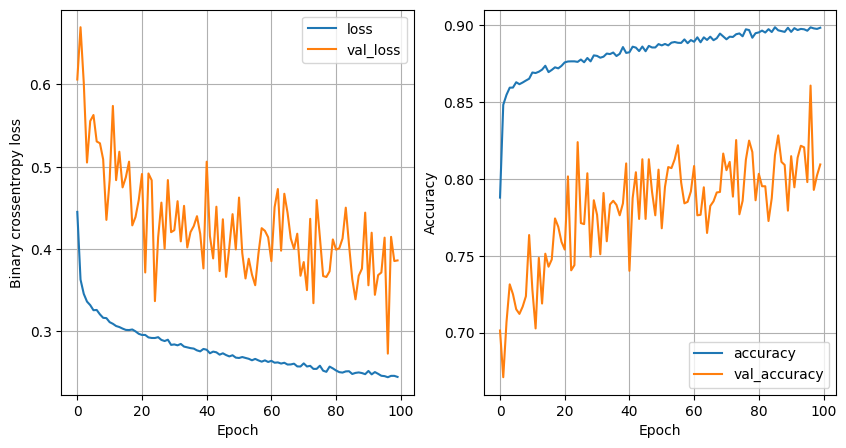

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8761 - loss: 0.3253
32 nodes, dropout0, lr 0.0001, batch_size 32


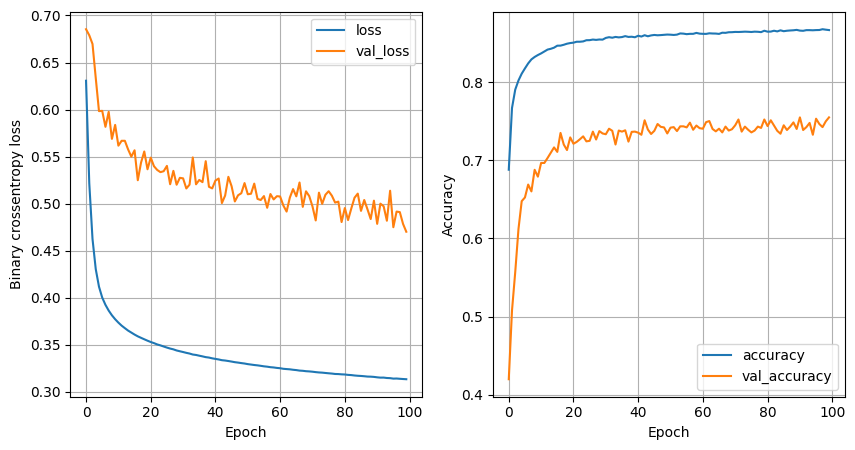

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8707 - loss: 0.3073
32 nodes, dropout0, lr 0.0001, batch_size 64


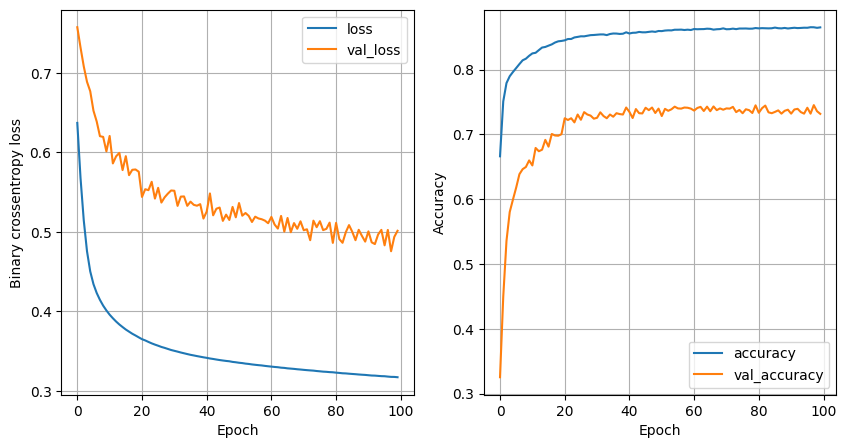

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8713 - loss: 0.3113
32 nodes, dropout0, lr 0.0001, batch_size 128


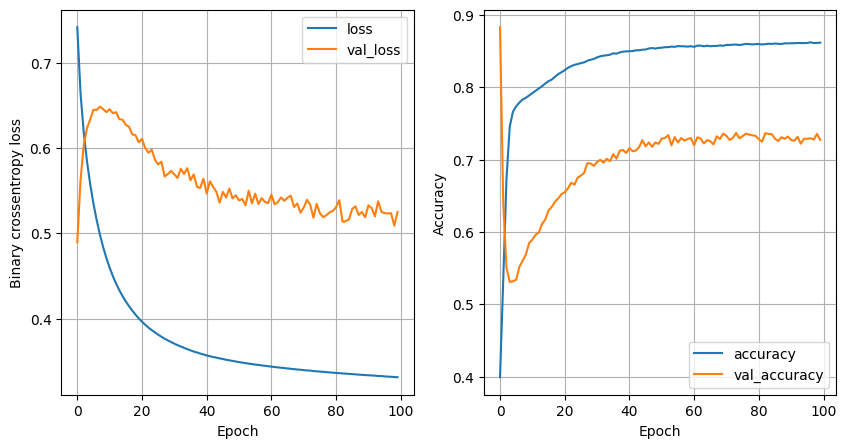

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8730 - loss: 0.3239
32 nodes, dropout0.2, lr 0.01, batch_size 32


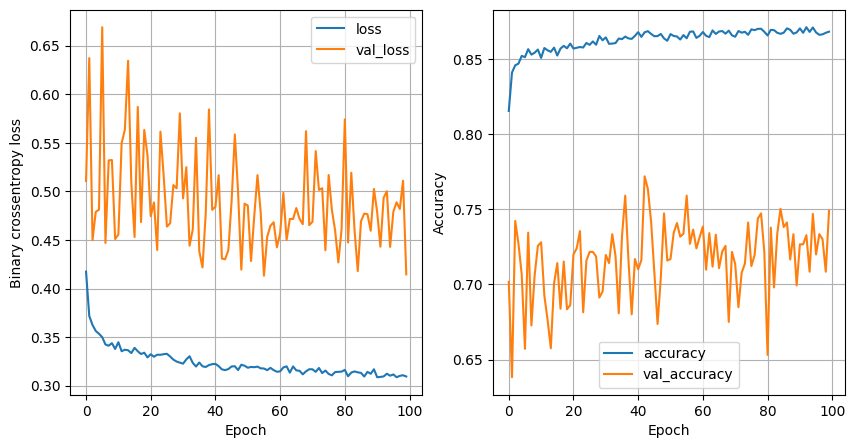

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8763 - loss: 0.3093
32 nodes, dropout0.2, lr 0.01, batch_size 64


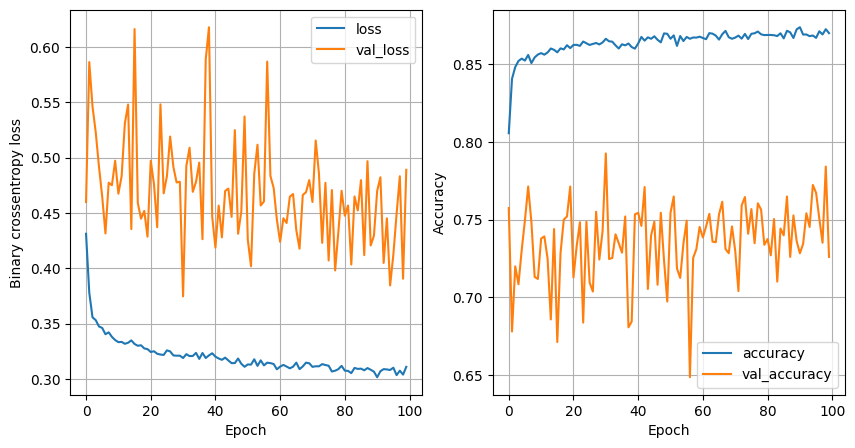

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.2990
32 nodes, dropout0.2, lr 0.01, batch_size 128


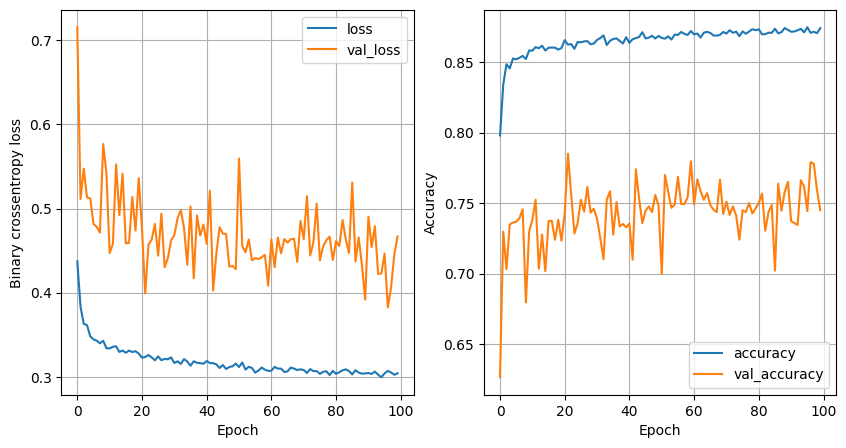

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8770 - loss: 0.2974
32 nodes, dropout0.2, lr 0.005, batch_size 32


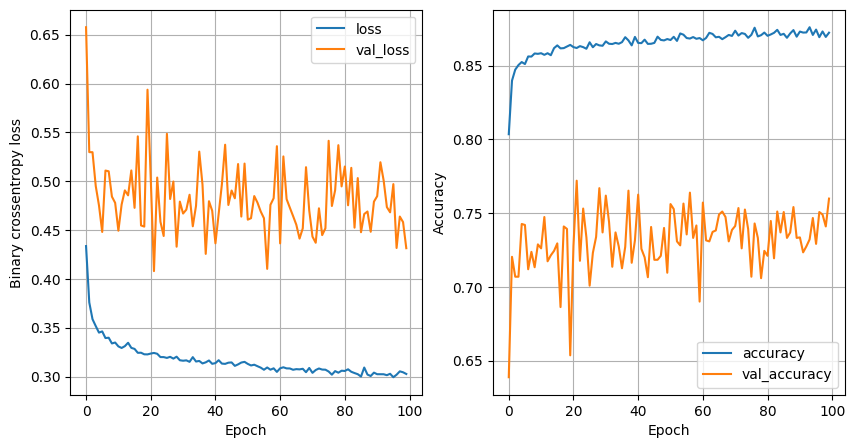

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8721 - loss: 0.2996
32 nodes, dropout0.2, lr 0.005, batch_size 64


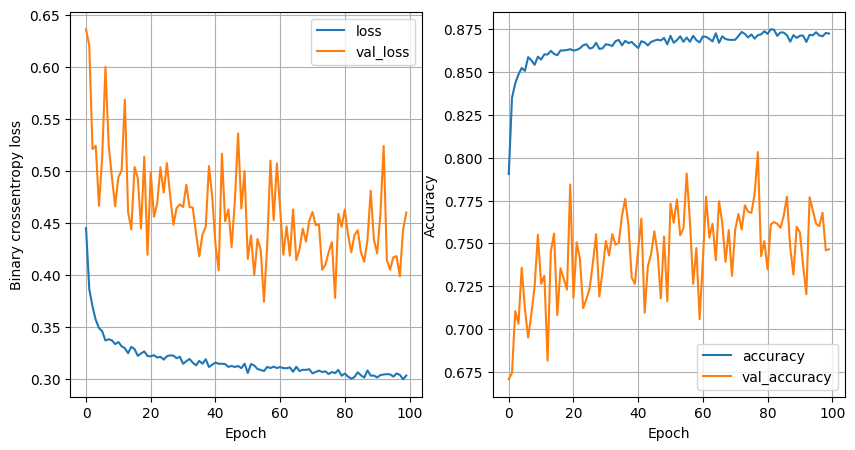

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8781 - loss: 0.2980
32 nodes, dropout0.2, lr 0.005, batch_size 128


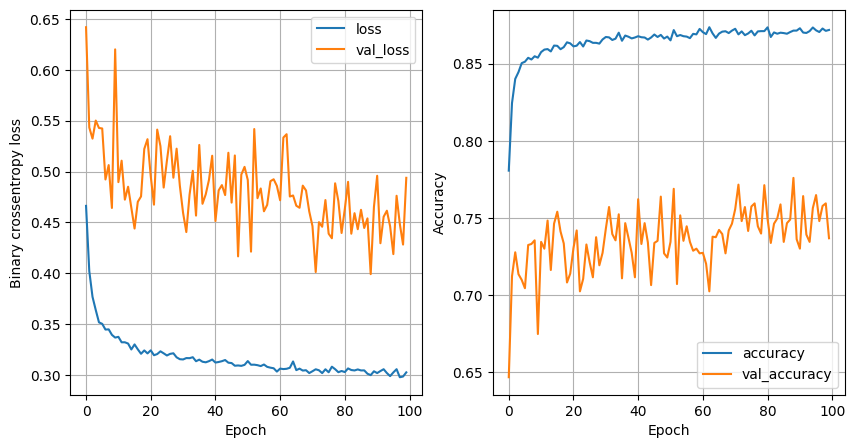

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8783 - loss: 0.2999
32 nodes, dropout0.2, lr 0.0001, batch_size 32


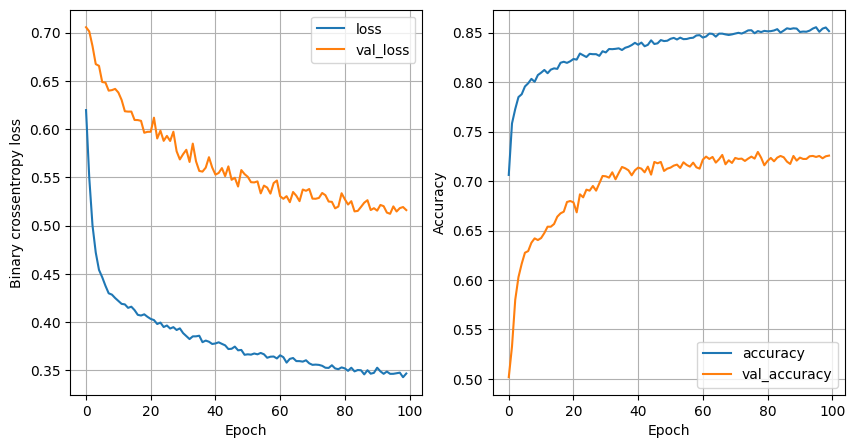

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8716 - loss: 0.3143
32 nodes, dropout0.2, lr 0.0001, batch_size 64


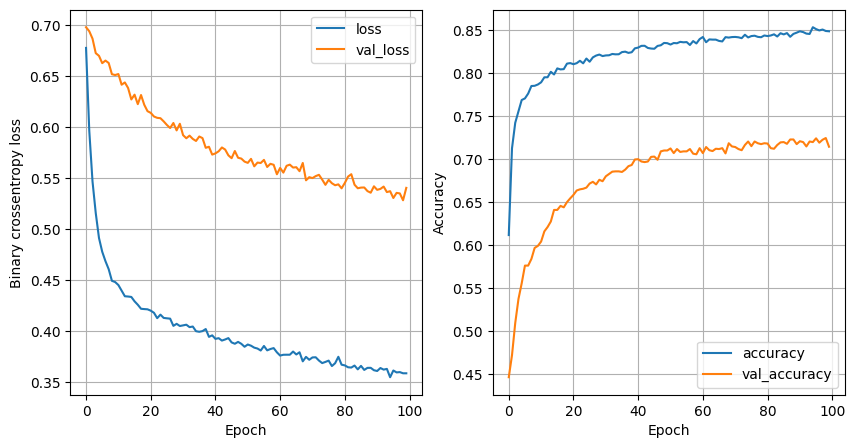

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3222
32 nodes, dropout0.2, lr 0.0001, batch_size 128


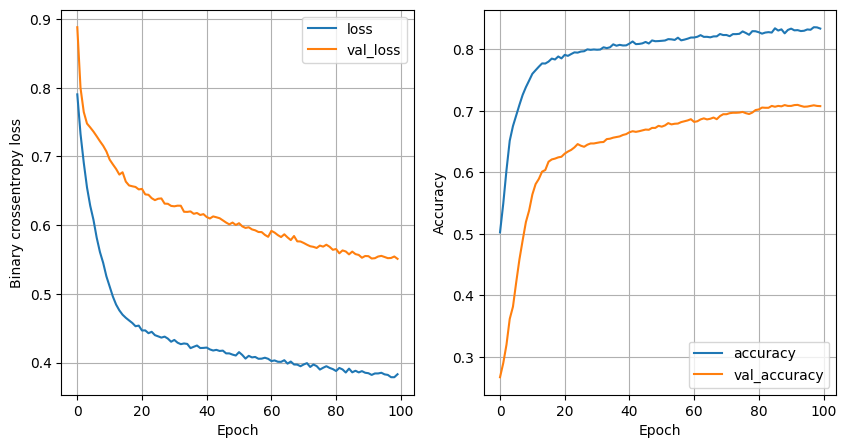

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8656 - loss: 0.3365
64 nodes, dropout0, lr 0.01, batch_size 32


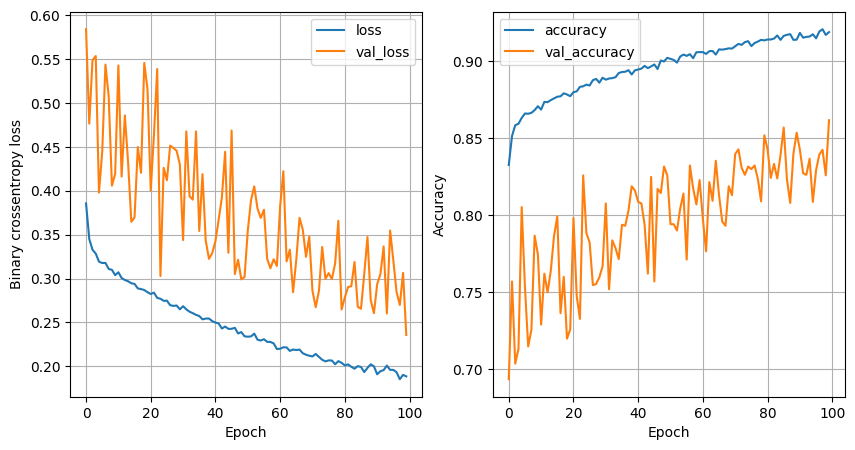

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8696 - loss: 0.4851
64 nodes, dropout0, lr 0.01, batch_size 64


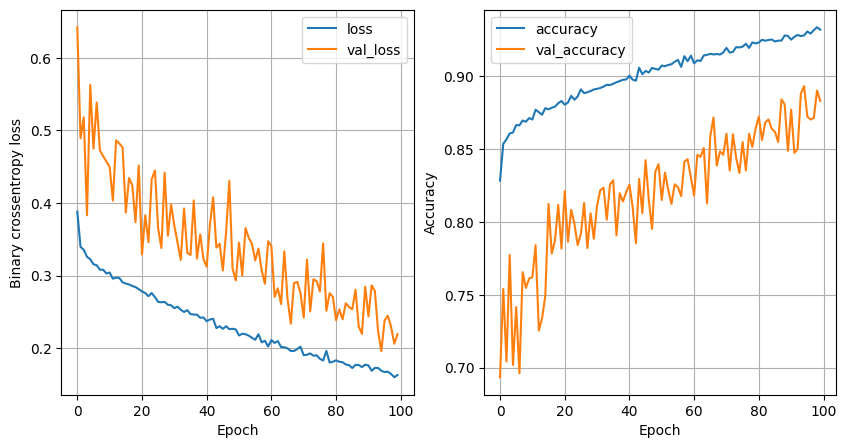

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8562 - loss: 0.5772
64 nodes, dropout0, lr 0.01, batch_size 128


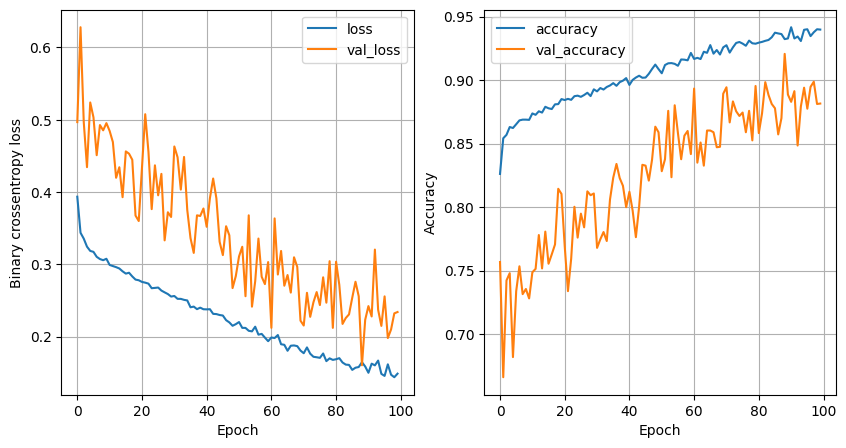

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8554 - loss: 0.5864
64 nodes, dropout0, lr 0.005, batch_size 32


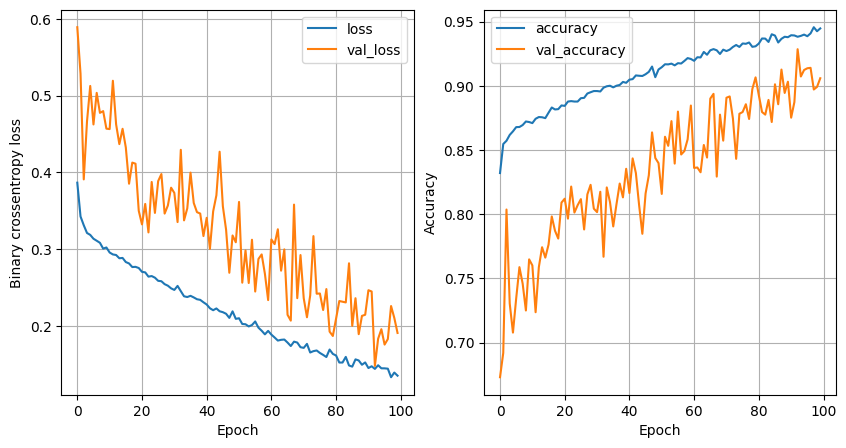

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.6421
64 nodes, dropout0, lr 0.005, batch_size 64


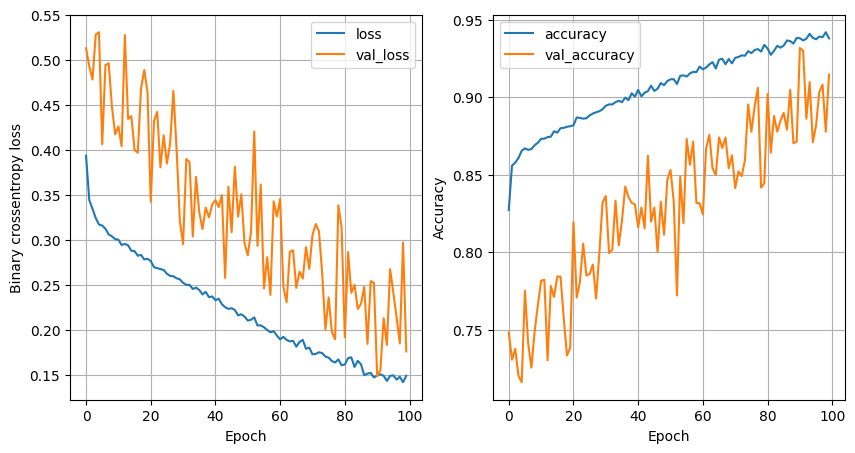

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8579 - loss: 0.5350
64 nodes, dropout0, lr 0.005, batch_size 128


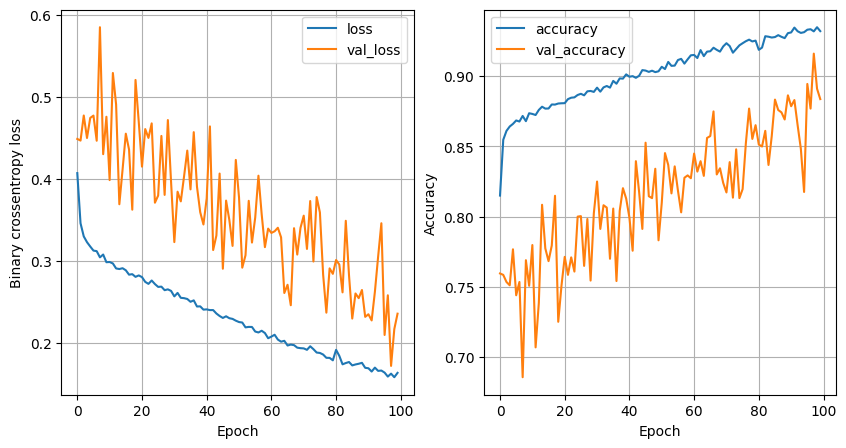

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8540 - loss: 0.4555
64 nodes, dropout0, lr 0.0001, batch_size 32


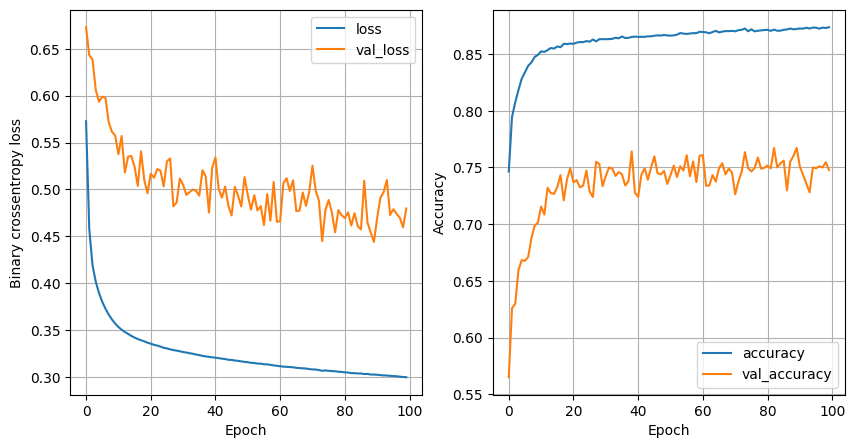

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8743 - loss: 0.3030
64 nodes, dropout0, lr 0.0001, batch_size 64


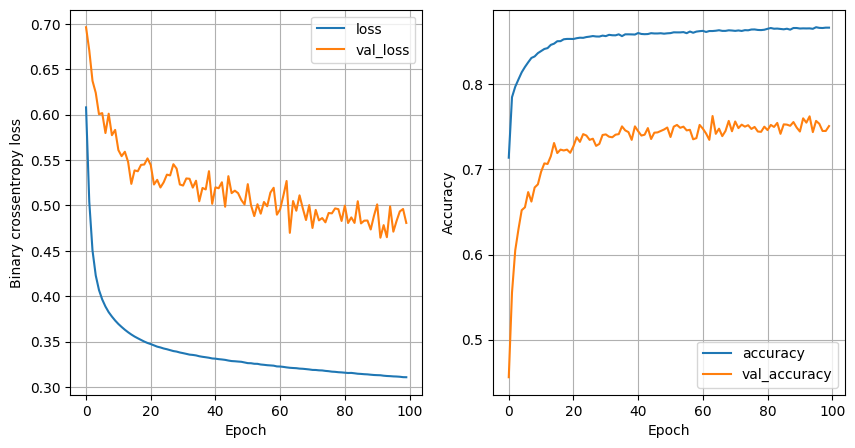

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8727 - loss: 0.3080
64 nodes, dropout0, lr 0.0001, batch_size 128


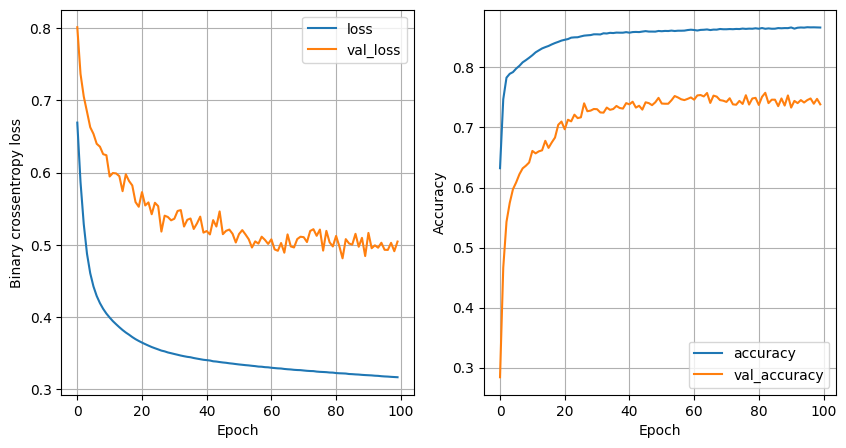

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3095
64 nodes, dropout0.2, lr 0.01, batch_size 32


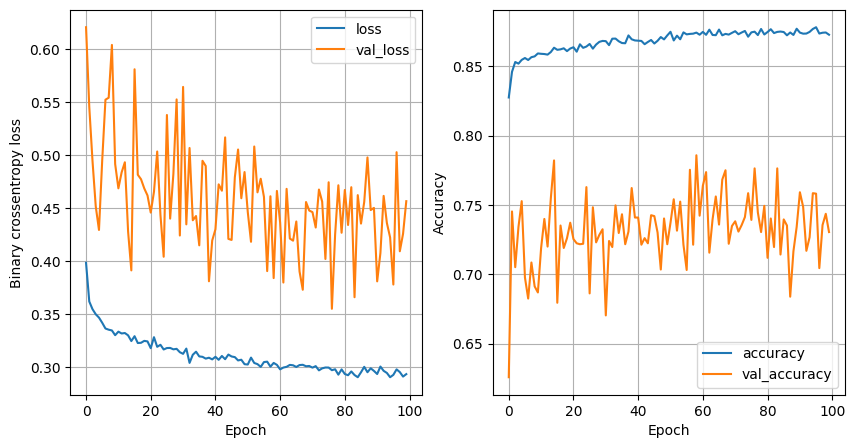

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8684 - loss: 0.3285
64 nodes, dropout0.2, lr 0.01, batch_size 64


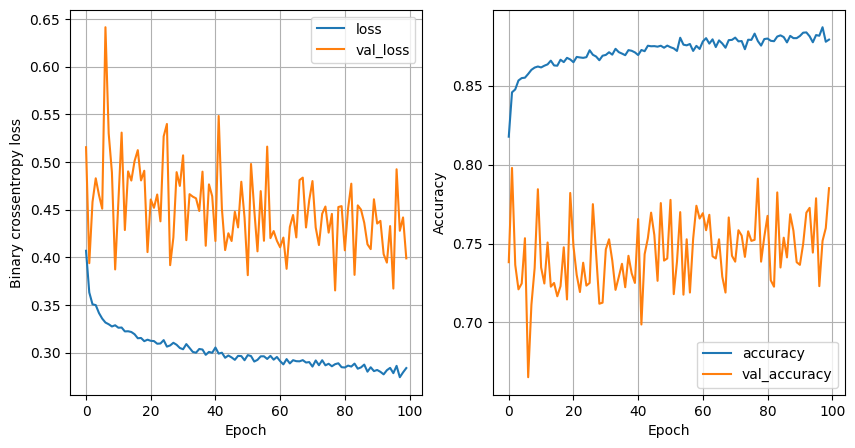

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8859 - loss: 0.3030
64 nodes, dropout0.2, lr 0.01, batch_size 128


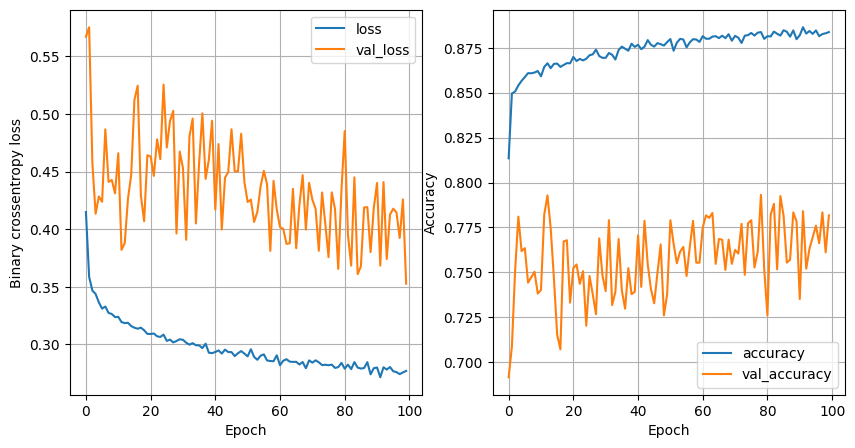

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.3082
64 nodes, dropout0.2, lr 0.005, batch_size 32


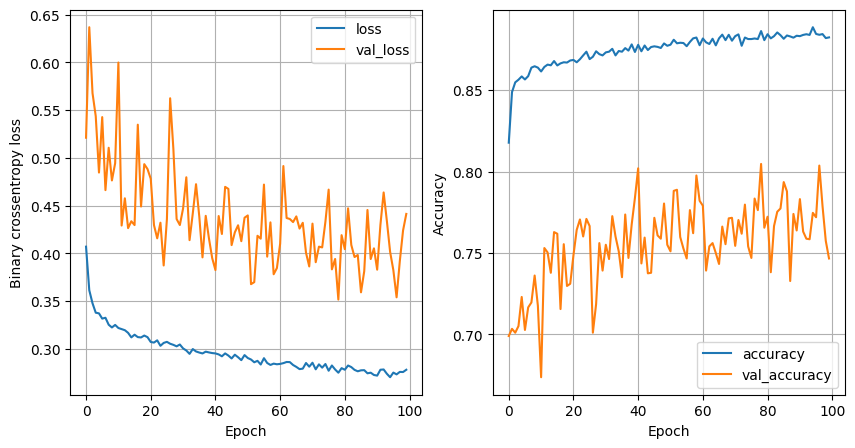

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8747 - loss: 0.3040
64 nodes, dropout0.2, lr 0.005, batch_size 64


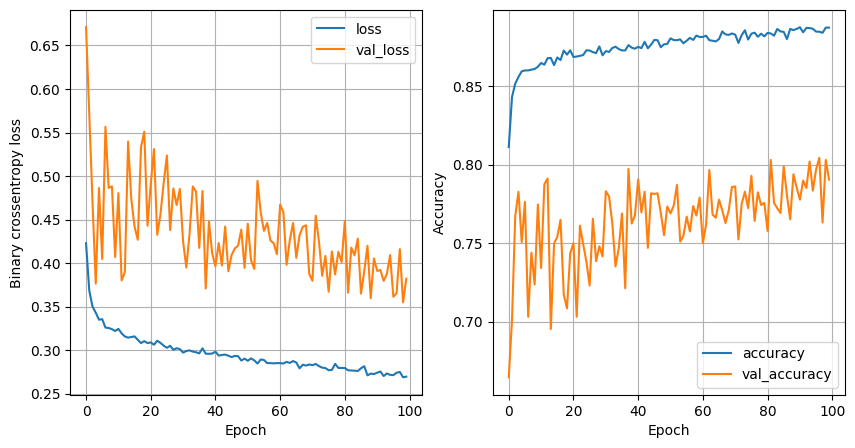

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.2956
64 nodes, dropout0.2, lr 0.005, batch_size 128


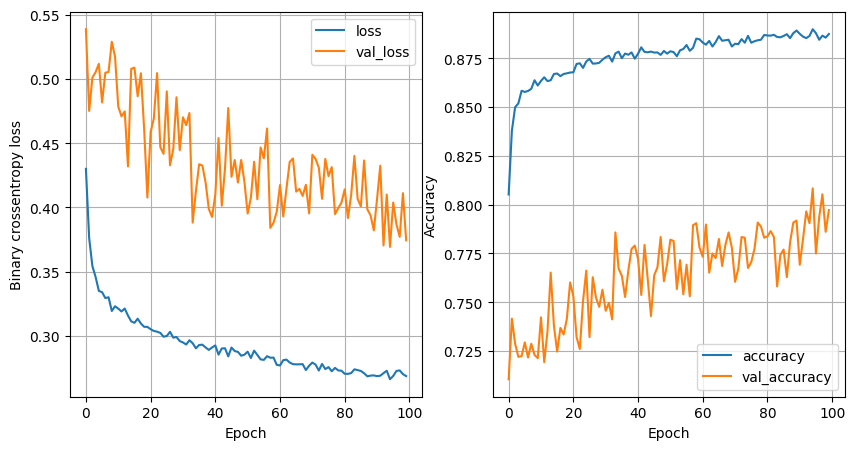

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8809 - loss: 0.2959
64 nodes, dropout0.2, lr 0.0001, batch_size 32


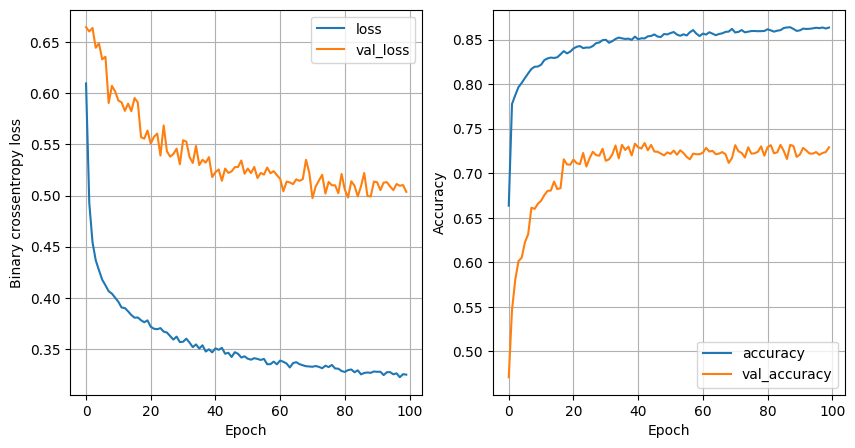

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8718 - loss: 0.3019
64 nodes, dropout0.2, lr 0.0001, batch_size 64


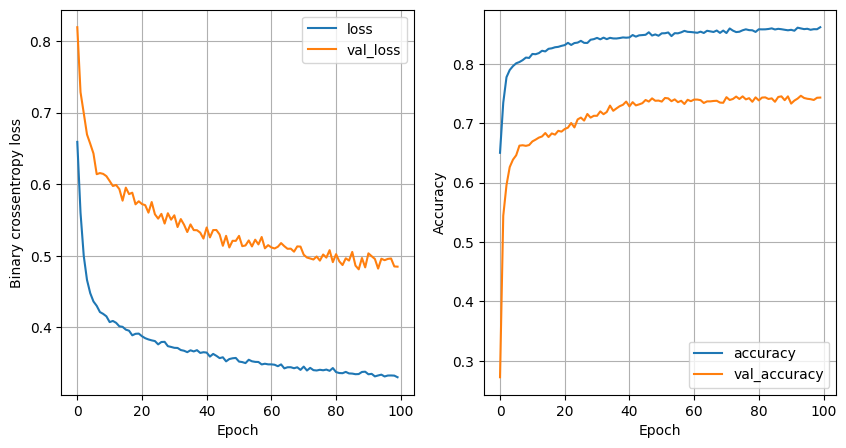

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8758 - loss: 0.3034
64 nodes, dropout0.2, lr 0.0001, batch_size 128


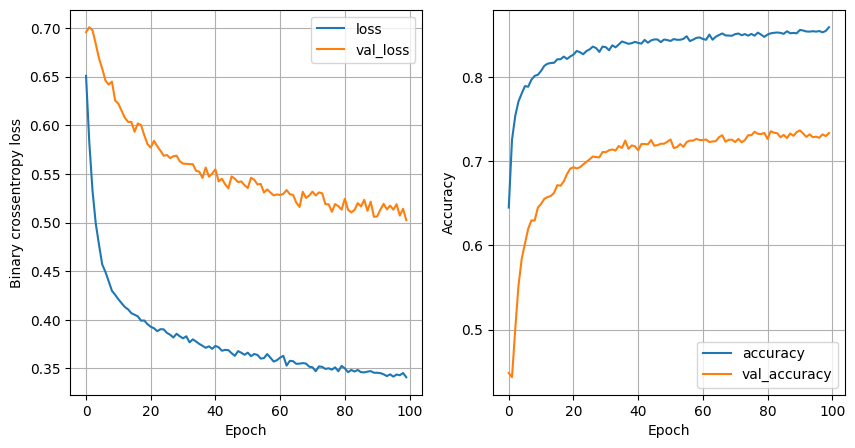

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8714 - loss: 0.3120


In [19]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 100
for num_node in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.0001]:
      for batch_size in [32, 64, 128]:
        print(f"{num_node} nodes, dropout{dropout_prob}, lr {lr}, batch_size {batch_size}")
        nn_model, history = train_model(x_train, y_train, num_node, lr, dropout_prob, batch_size, epochs)
        plot_history(history)
        val_loss = nn_model.evaluate(x_valid, y_valid)[0]
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = nn_model


In [25]:
y_pred=least_loss_model.predict(x_test)
y_pred=(y_pred>0.5).astype(int)
y_pred

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1],
       [0],
       [0],
       ...,
       [1],
       [1],
       [0]])

In [20]:
y_pred = least_loss_model.predict(x_test)  # Get predictions
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)  # Fix the reshape
print(classification_report(y_test, y_pred))

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.87      0.74      0.80      1331
           1       0.87      0.94      0.90      2473

    accuracy                           0.87      3804
   macro avg       0.87      0.84      0.85      3804
weighted avg       0.87      0.87      0.87      3804



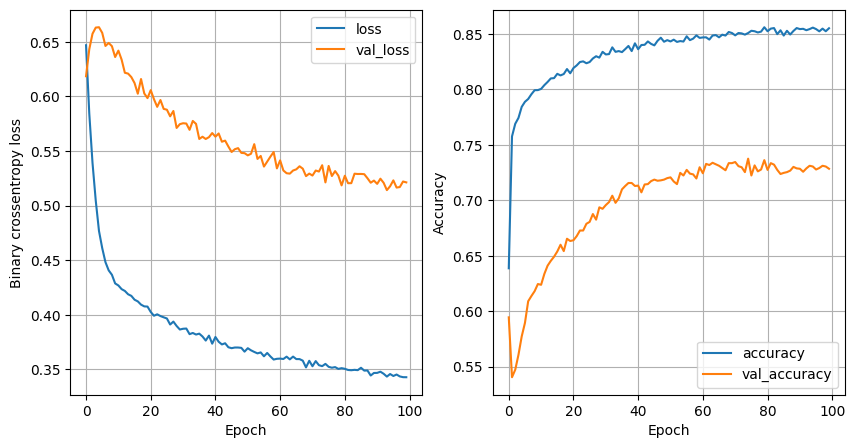

In [14]:
plot_history(history)

Regression models

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import copy
import seaborn
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [6]:
dataset_cols = ["Bike_Count", "Hour", "Temp", "Humidity", "Wind", "Visibility", "Dew_point_temp", "Radiation", "Rain", "Snow", "Functioning"]
df = pd.read_csv("SeoulBikeData.csv").drop(["Date", "Holiday", "Seasons"], axis=1)
df.head()



,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [7]:
df.columns = dataset_cols
df["Functioning"] = (df["Functioning"] == "Yes").astype(int)
df = df[df["Hour"] == 12]
df = df.drop(["Hour"], axis = 1)
df.head()

,Bike_Count,Temp,Humidity,Wind,Visibility,Dew_point_temp,Radiation,Rain,Snow,Functioning
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


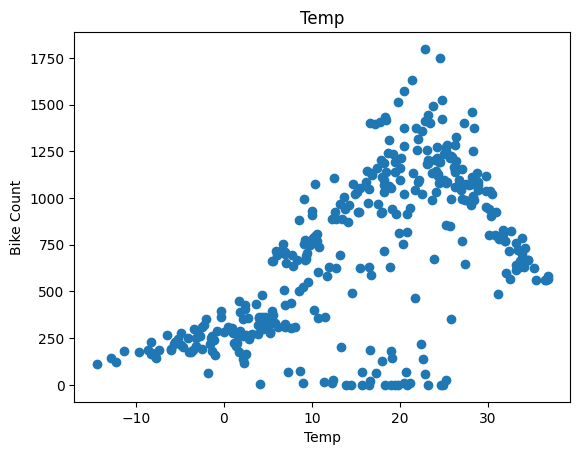

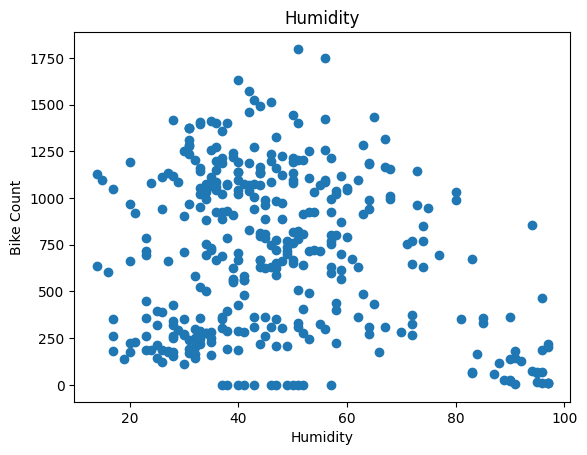

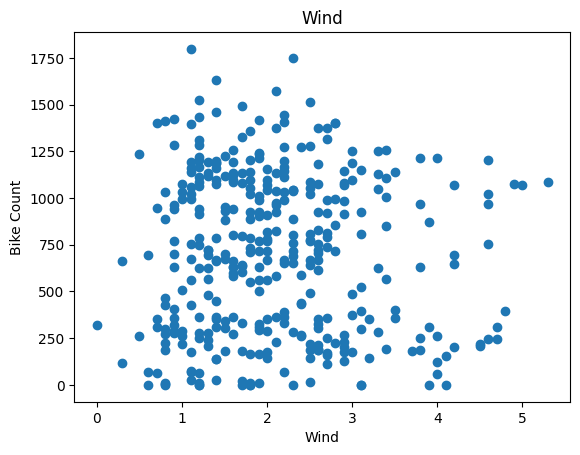

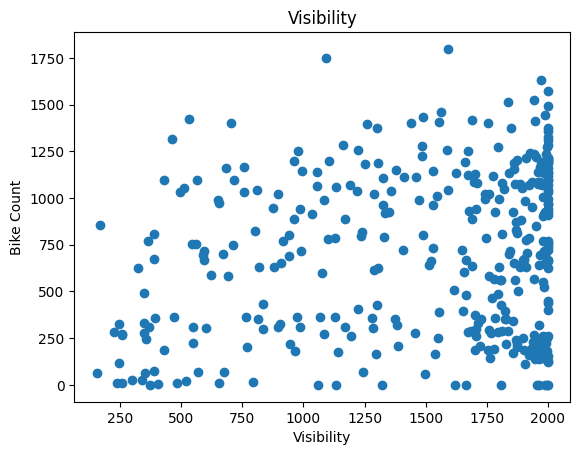

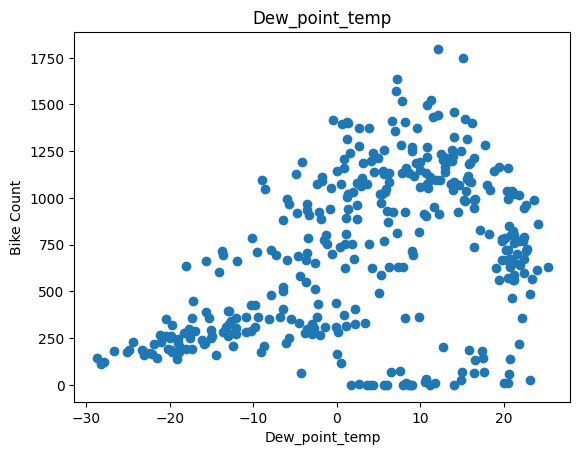

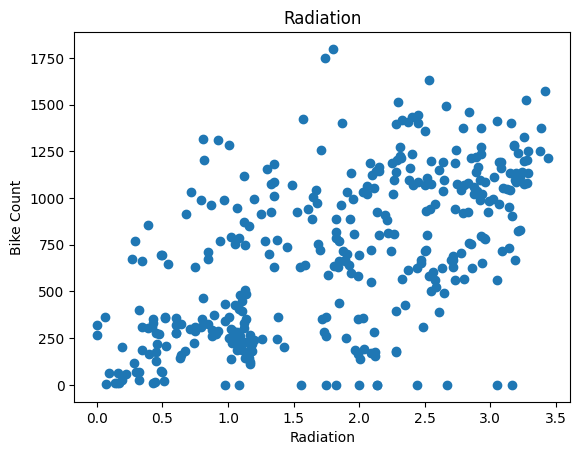

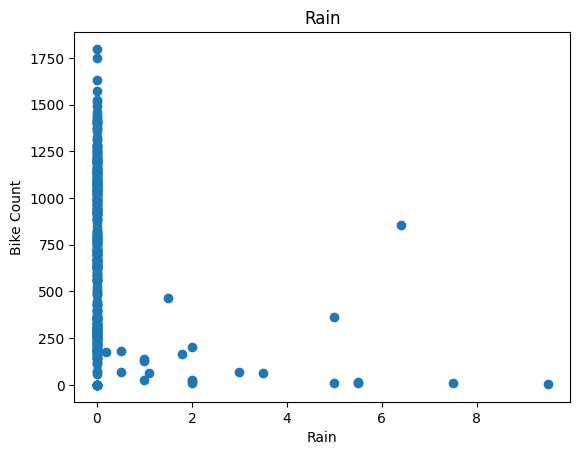

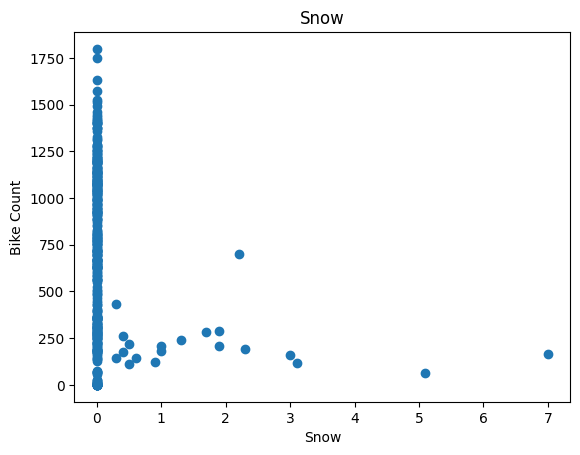

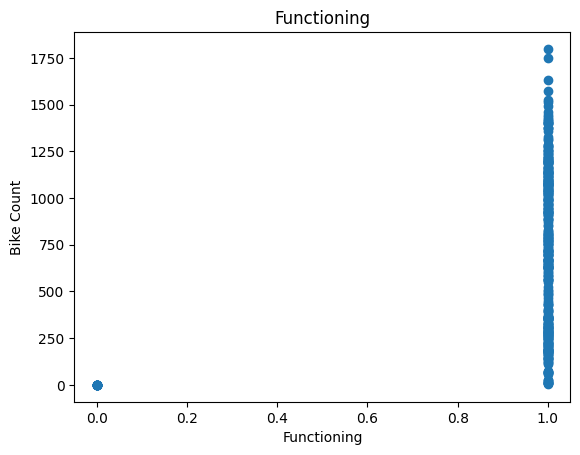

'\n   # Add a trend line\n  m, b = np.polyfit(df[label], df["Bike_Count"], 1)  # Linear regression\n  plt.plot(df[label], m * df[label] + b, color=\'red\', linestyle=\'--\')  # Add trend line\n    \n    # Display correlation coefficient\n  correlation = df[label].corr(df["Bike_Count"])\n  plt.annotate(f"Corr: {correlation:.2f}", xy=(0.05, 0.95), xycoords="axes fraction", \n                 fontsize=10, color="blue", backgroundcolor="white")\n  '

In [8]:
for label in df.columns[1:]:
  plt.scatter(df[label], df["Bike_Count"])
  plt.title(label)
  plt.ylabel("Bike Count")
  plt.xlabel(label)
  plt.show()
'''
   # Add a trend line
  m, b = np.polyfit(df[label], df["Bike_Count"], 1)  # Linear regression
  plt.plot(df[label], m * df[label] + b, color='red', linestyle='--')  # Add trend line

    # Display correlation coefficient
  correlation = df[label].corr(df["Bike_Count"])
  plt.annotate(f"Corr: {correlation:.2f}", xy=(0.05, 0.95), xycoords="axes fraction",
                 fontsize=10, color="blue", backgroundcolor="white")
  '''

In [9]:
#Remove columns that seem not to have a linear relationship with the Bike Counts as shown in the graphs
df = df.drop(["Wind", "Visibility", "Functioning"], axis=1)
df.head()

,Bike_Count,Temp,Humidity,Dew_point_temp,Radiation,Rain,Snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


TRAIN/VALID/TEST DATASET

In [10]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [13]:
def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    if not x_labels:
        x = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if len(x_labels) == 1:
            x = dataframe[x_labels[0]].values.reshape(-1, 1)
        else:
            x = dataframe[x_labels].values
        # The 'data' variable is now assigned regardless of the condition.
        y = dataframe[y_label].values.reshape(-1, 1)  # Define y here
        data = np.hstack((x, y))  # Assign data outside the nested if
    # Now 'data' is accessible for all branches.
    # y = dataframe[y_label].values.reshape(-1, 1)  # Moved this line earlier
    return data, x, y

In [37]:
_, x_train_temp, y_train_temp = get_xy(train, "Bike_Count", x_labels=["Temp"])
_, x_valid_temp, y_valid_temp = get_xy(valid, "Bike_Count", x_labels=["Temp"])
_, x_test_temp, y_test_temp = get_xy(test, "Bike_Count", x_labels=["Temp"])

In [19]:
x_train_temp

array([[ 10. ],
       [ 25.9],
       [  1.2],
       [ 22.1],
       [  5.9],
       [  7.7],
       [ 31.7],
       [ -7.8],
       [ -7.7],
       [ 23.2],
       [ 31.9],
       [ 33.2],
       [ 20.3],
       [ -1.3],
       [ 21.7],
       [-11.3],
       [ 20.5],
       [  9.6],
       [ 19.5],
       [  9. ],
       [  9. ],
       [ 18.8],
       [ 28.3],
       [ 12.7],
       [  6. ],
       [ -5.2],
       [ 12.6],
       [  4.3],
       [ 17.2],
       [ 28.7],
       [ 27.1],
       [  2.2],
       [ -3.7],
       [ -7.3],
       [ 25. ],
       [ 32.5],
       [ 24.8],
       [  2.2],
       [ 25.2],
       [ 21.8],
       [ -5.5],
       [ 19. ],
       [ 22.9],
       [  1.6],
       [ 11.4],
       [ 24.1],
       [ 27. ],
       [ 19.1],
       [ -3.4],
       [ 30.8],
       [  7.6],
       [ 33.8],
       [ 17.5],
       [ 12.8],
       [ 10.8],
       [  5.8],
       [ 18.8],
       [ 31.1],
       [  4.8],
       [ 33.7],
       [ -6. ],
       [ 13.4],
       [

In [20]:
#CREATE A REGRESSOR
temp_regressor = LogisticRegression()
temp_regressor.fit(x_train_temp, y_train_temp)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
temp_regressor.score(x_test_temp, y_test_temp)

0.0273972602739726

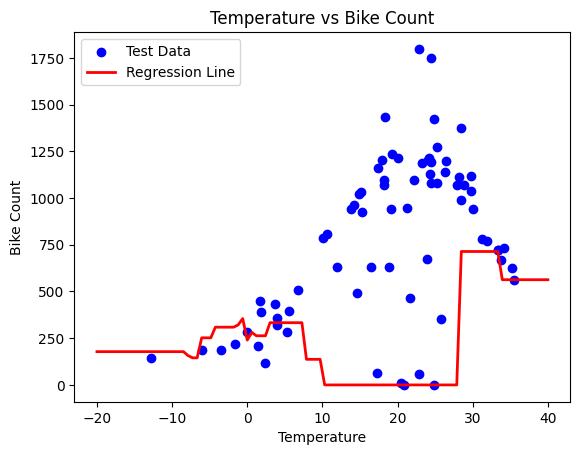

In [29]:
plt.scatter(x_test_temp, y_test_temp, label="Test Data", color="Blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_regressor.predict(np.array(x).reshape(-1, 1)), label="Regression Line", color="Red", linewidth=2)
plt.legend()
plt.title("Temperature vs Bike Count")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.show()


Regression with Neural Net

In [46]:
def plot_history(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

In [40]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=[1,], axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])
temp_nn_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.1),
                      loss='mean_absolute_error')
history = temp_nn_model.fit(
    x_train_temp.reshape(-1), y_train_temp.reshape(-1),
    verbose=0,
    epochs=1000,
    validation_data=(x_valid_temp, y_valid_temp1)
    )

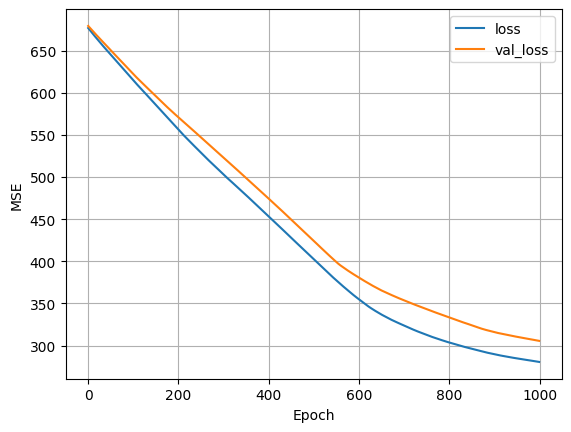

In [47]:
plot_history(history)

NEURAL NET

In [ ]:
nn_model = tf.keras.Sequential([
    tf